In [1]:
import sys
sys.path.append('..')

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numcodecs import Blosc

import torch

In [2]:
npz_path = os.path.join(r"..\data\DEMs", "20240520_1200_lp_128.npz")
npz = np.load(npz_path)

In [3]:
npz.files

['DEMCube',
 'DEMCubeShape',
 'AIACube',
 'AIAErrors',
 'AIACubeShape',
 'logT',
 'scaleFactor']

In [4]:
AIACube = npz["AIACube"]
AIAErrors = npz["AIAErrors"]
DEMCube = npz["DEMCube"]
logT = npz["logT"]

compressor = Blosc(cname='zstd', clevel=4, shuffle=2)

AIACube = np.frombuffer(compressor.decode(AIACube), dtype=np.float32).reshape(npz['AIACubeShape'])
AIAErrors = np.frombuffer(compressor.decode(AIAErrors), dtype=np.float32).reshape(npz['AIACubeShape'])

DEMCube = np.frombuffer(compressor.decode(DEMCube), dtype=np.float32).reshape(npz['DEMCubeShape'])

In [5]:
AIACube.shape, AIAErrors.shape, DEMCube.shape, logT.shape

((6, 4096, 4096), (6, 4096, 4096), (18, 32, 32), (18,))

In [6]:
decimate = 128

In [7]:
AIACube = AIACube[:, ::decimate, ::decimate]
AIAErrors = AIAErrors[:, ::decimate, ::decimate]

In [8]:
AIACube.shape, AIAErrors.shape

((6, 32, 32), (6, 32, 32))

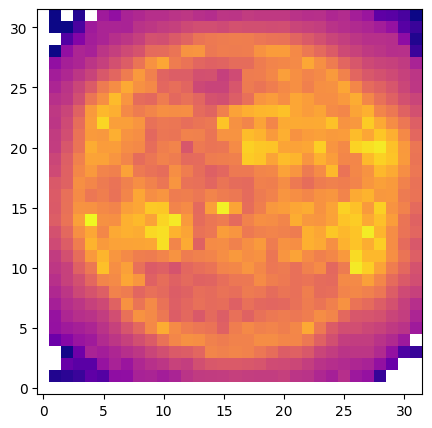

In [9]:
from matplotlib.colors import LogNorm

AIA = AIACube.sum(axis=0)

plt.figure(figsize=(5, 5))
plt.imshow(
        AIA,
        origin='lower',
        cmap='plasma',
        norm=LogNorm(
            vmin=max(1, AIA.min()),
            vmax=AIA.max()
        )
)
plt.show()

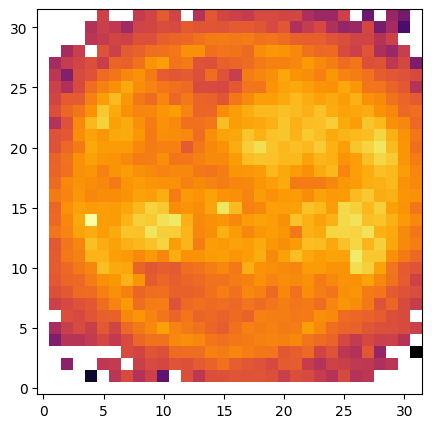

In [10]:
EM = DEMCube.sum(axis=0)
positive = EM[np.isfinite(EM) & (EM > 0)]

plt.figure(figsize=(5,5))
plt.imshow(
    EM,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(
        vmin=positive.min(),
        vmax=positive.max()
    )
)

plt.show()

In [11]:
n = 16 

H, W = AIACube.shape[1], AIACube.shape[2]

# elegimos una región cerca del centro del disco (ahí suele haber señal real,
# lejos de bordes donde puede haber NaN por el registro/padding)
start_y = H // 2 - n // 2
start_x = W // 2 - n // 2

aia_patch = AIACube[:, start_y:start_y+n, start_x:start_x+n]      # (C, n, n)
err_patch = AIAErrors[:, start_y:start_y+n, start_x:start_x+n]    # (C, n, n)
dem_patch = DEMCube[:, start_y:start_y+n, start_x:start_x+n]      # (nBins, n, n)

print("aia_patch:", aia_patch.shape)
print("err_patch:", err_patch.shape)
print("dem_patch:", dem_patch.shape)

# chequeo importante: que no haya NaN en el parche elegido
print("NaNs en aia_patch:", np.isnan(aia_patch).sum())
print("NaNs en dem_patch:", np.isnan(dem_patch).sum())

aia_patch: (6, 16, 16)
err_patch: (6, 16, 16)
dem_patch: (18, 16, 16)
NaNs en aia_patch: 0
NaNs en dem_patch: 0


In [12]:
device = torch.device("cpu")

aia_input  = torch.from_numpy(aia_patch).double().unsqueeze(0).to(device)   # (1, C, n, n)
aia_errors = torch.from_numpy(err_patch).double().unsqueeze(0).to(device)   # (1, C, n, n)
dem_true   = torch.from_numpy(dem_patch).double().unsqueeze(0).to(device)   # (1, nBins, n, n)

print(aia_input.shape, aia_errors.shape, dem_true.shape)

torch.Size([1, 6, 16, 16]) torch.Size([1, 6, 16, 16]) torch.Size([1, 18, 16, 16])


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10884\1845149019.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  aia_input  = torch.from_numpy(aia_patch).double().unsqueeze(0).to(device)   # (1, C, n, n)


In [14]:
from src.utils import getBasis 

RData_raw = np.load("../RData.npz") 
R, logT = RData_raw['R'], RData_raw['logT']

print("R original:", R.shape)
print("logT:", logT.shape)         

# Escalar R 
scale = 10**26
R = (R * scale).astype(np.float64)

# Construir la base expandida B 
basisAlphas = [0.0, 0.1, 0.2]
B = getBasis(R, logT, basisAlphas)

print("B:", B.shape)

# D = R @ B: matriz total coef.
D = R @ B
print("D:", D.shape)   # esperado: (6, 54)

# Pasar a tensores torch 
R_t = torch.tensor(R, dtype=torch.float64, device=device)
B_t = torch.tensor(B, dtype=torch.float64, device=device)
D_t = torch.tensor(D, dtype=torch.float64, device=device)

R original: (6, 18)
logT: (18,)
B: (18, 54)
D: (6, 54)


In [15]:
import torch.nn.functional as F
from src.model import DemoModel

device = torch.device("cpu")

model = DemoModel().double().to(device)   

# forward + positividad
raw_output = model(aia_input)              
dem_pred = F.softplus(raw_output) # (1, 18, 16, 16), garantizado > 0

print(dem_pred.shape)

torch.Size([1, 18, 16, 16])


In [16]:
from torch import nn

class MaskedMSELoss(nn.Module):
    # masked MSE loss for nans
    def __init__(self, R=None, B=None):
        super().__init__()
        # response matrix R
        self.R = R 
        # basis matrix B
        self.B = B

    def forward(self, pred, target):
        mask = ~torch.isnan(target)
        diff = pred[mask] - target[mask]
        return torch.mean(diff ** 2)
    
loss_fn = MaskedMSELoss()

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

n_steps = 10000

for step in range(n_steps):
    optimizer.zero_grad()

    raw_output = model(aia_input)          # (1, 18, n, n)
    dem_pred = F.softplus(raw_output)      # forzamos positividad

    loss = loss_fn(dem_pred, dem_true)

    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(f"step {step:5d}  loss: {loss.item():.6f}")

print(f"loss final: {loss.item():.6f}")

step     0  loss: 9.825149
step  1000  loss: 0.474506
step  2000  loss: 0.248543
step  3000  loss: 0.127935
step  4000  loss: 0.096252
step  5000  loss: 0.070445
step  6000  loss: 0.074392
step  7000  loss: 0.043061
step  8000  loss: 0.153876
step  9000  loss: 0.056718
loss final: 0.024818


In [24]:
def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

In [36]:
with torch.no_grad():
    dem_pred_final = F.softplus(model(aia_input)).squeeze(0).numpy()  # (18, n, n)

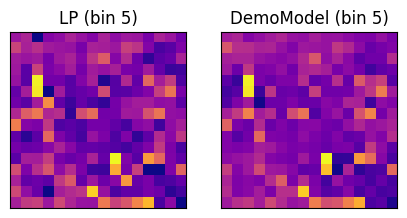

In [51]:
bin_i = 5

vmin = dem_true[0, bin_i].sqrt().min().item()
vmax = dem_true[0, bin_i].sqrt().max().item()

fig, axs = plt.subplots(1, 2, figsize=(5,4))

axs[0].imshow(
    dem_true[0, bin_i].sqrt().numpy(),
    cmap="plasma",
    vmin=vmin,
    vmax=vmax
)

axs[0].set_title(f"LP (bin {bin_i})")

axs[1].imshow(
    np.sqrt(dem_pred_final[bin_i]),
    cmap="plasma",
    vmin=vmin,
    vmax=vmax
)

axs[1].set_title(f"DemoModel (bin {bin_i})")

for ax in axs:
    style_ax(ax)

plt.show()

In [39]:
from scipy.spatial.distance import jensenshannon

def js_map(dem1: np.ndarray, dem2: np.ndarray) -> np.ndarray:
    _, H, W = dem1.shape
    dist_map = np.zeros((H, W))

    for i in range(H):
        for j in range(W):
            w1 = dem1[:, i, j]
            w2 = dem2[:, i, j]

            if not (np.isfinite(w1).all() and np.isfinite(w2).all()):
                dist_map[i, j] = np.nan
                continue

            dist_map[i, j] = jensenshannon(w1, w2)

    return dist_map

In [40]:
js_map = js_map(dem_true.squeeze(0).numpy(), dem_pred_final)

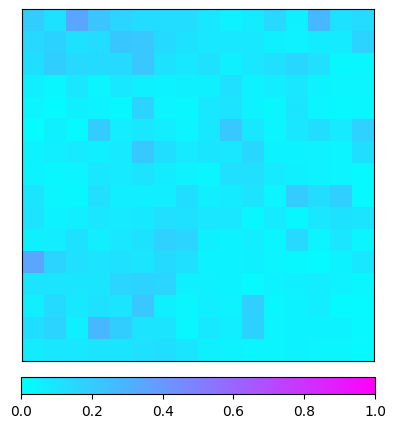

In [49]:
fig, ax = plt.subplots(figsize=(5, 5))

img = ax.imshow(js_map, cmap='cool', vmin=0, vmax=1)

style_ax(ax)

fig.colorbar(
    img,
    ax=ax,
    orientation='horizontal',
    fraction=0.046,
    pad=0.04,
)

plt.show()